# Predictive Workforce Planning Using HR Recruitment Analytics
## Step 2: Exploratory Data Analysis (EDA)

**Objective:** Explore the cleaned HR dataset to identify hiring trends, 
seasonal patterns, departmental activity, attrition drivers, and 
recruitment source effectiveness.

**Input:** `../data/processed/HRDataset_Cleaned.csv`  
**Dataset:** 311 employee records | 6 departments | Hire years 2006–2018

##  Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global chart style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Libraries imported successfully")

Libraries imported successfully


## Load Cleaned Dataset

In [3]:
df = pd.read_csv('../data/processed/HRDataset_Cleaned.csv')

# Re-parse date columns (CSV doesn't preserve datetime types)
df['DateofHire']        = pd.to_datetime(df['DateofHire'],        errors='coerce')
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Hire Year Range : {df['HireYear'].min()} – {df['HireYear'].max()}")
print(f"Departments     : {sorted(df['Department'].unique())}")
print(f"Active          : {df['IsActive'].sum()} | Terminated: {(df['IsActive']==0).sum()}")

Dataset loaded: 311 rows × 41 columns
Hire Year Range : 2006 – 2018
Departments     : ['Admin Offices', 'Executive Office', 'IT/IS', 'Production', 'Sales', 'Software Engineering']
Active          : 207 | Terminated: 104


---
## 1. Annual Hiring Trend

How many employees were hired each year?  
This reveals overall growth or slowdown in recruitment activity over time.

## Hires Per Year Chart

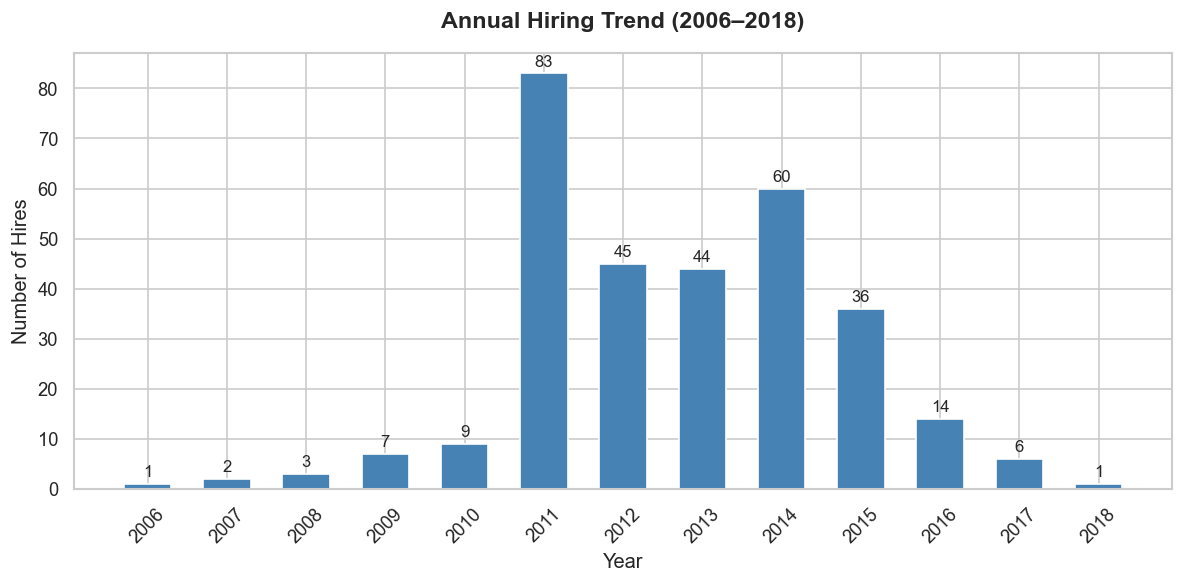

HireYear
2006     1
2007     2
2008     3
2009     7
2010     9
2011    83
2012    45
2013    44
2014    60
2015    36
2016    14
2017     6
2018     1


In [4]:
hires_per_year = df['HireYear'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(hires_per_year.index, hires_per_year.values, color='steelblue', edgecolor='white', width=0.6)

# Add value labels on bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_title('Annual Hiring Trend (2006–2018)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Hires')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/01_hires_per_year.png', bbox_inches='tight')
plt.show()

print(hires_per_year.to_string())

**Key Insight:** 2011 was the peak hiring year 
with 83 hires — likely a major expansion phase. 
Hiring declined gradually through 2016–2018.

---
## 2. Hiring by Department

Which departments account for the most hiring activity?  
This shows where workforce demand is concentrated.

## Hires by Department Chart

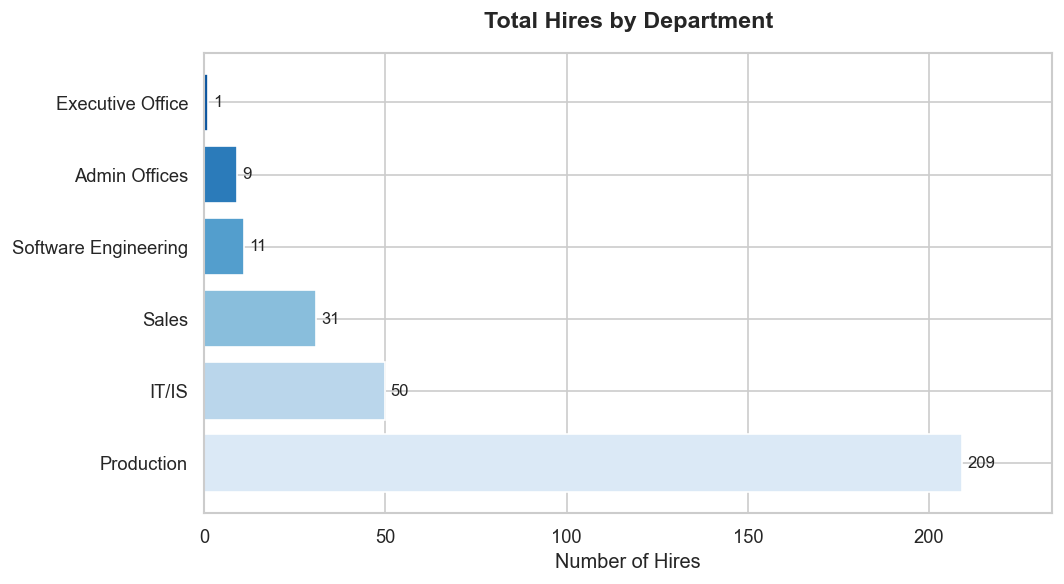

Department
Production              209
IT/IS                    50
Sales                    31
Software Engineering     11
Admin Offices             9
Executive Office          1


In [6]:
dept_counts = df['Department'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('Blues', len(dept_counts))
bars = ax.barh(dept_counts.index, dept_counts.values, color=colors, edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10)

ax.set_title('Total Hires by Department', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Hires')
ax.set_xlim(0, dept_counts.max() + 25)
plt.tight_layout()
plt.savefig('../outputs/figures/02_hires_by_department.png', bbox_inches='tight')
plt.show()

print(dept_counts.to_string())

**Key Insight:** Production dominates with 209 hires (67% of all hiring). IT/IS is second with 50. Executive Office has only 1 hire — expected for senior leadership.

---
## 3. Seasonal Hiring Patterns

Are there certain months where hiring peaks?  
Identifying seasonal patterns helps HR plan recruitment campaigns in advance.

## Monthly Hiring Pattern

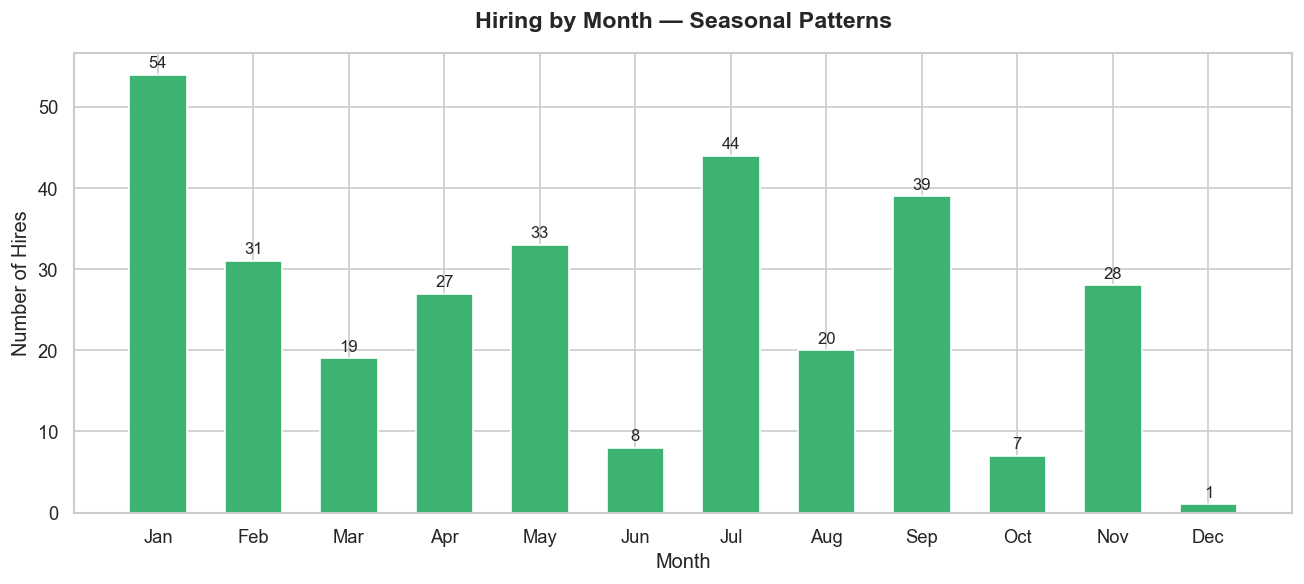

In [7]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
hires_per_month = df.groupby('HireMonthName')['EmpID'].count().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(hires_per_month.index, hires_per_month.values,
              color='mediumseagreen', edgecolor='white', width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_title('Hiring by Month — Seasonal Patterns', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Hires')
plt.tight_layout()
plt.savefig('../outputs/figures/03_seasonal_hiring.png', bbox_inches='tight')
plt.show()

**Key Insight:** January (54), July (44), and September (39) are peak hiring months. December (1) and June (8) are the quietest — suggesting hiring pauses around mid-year and year-end holidays.

---
## 4. Department Hiring Trend Over Time

How has each department's hiring changed year by year?  
This reveals which departments are growing, shrinking, or staying flat.

## Department Trend Over Years

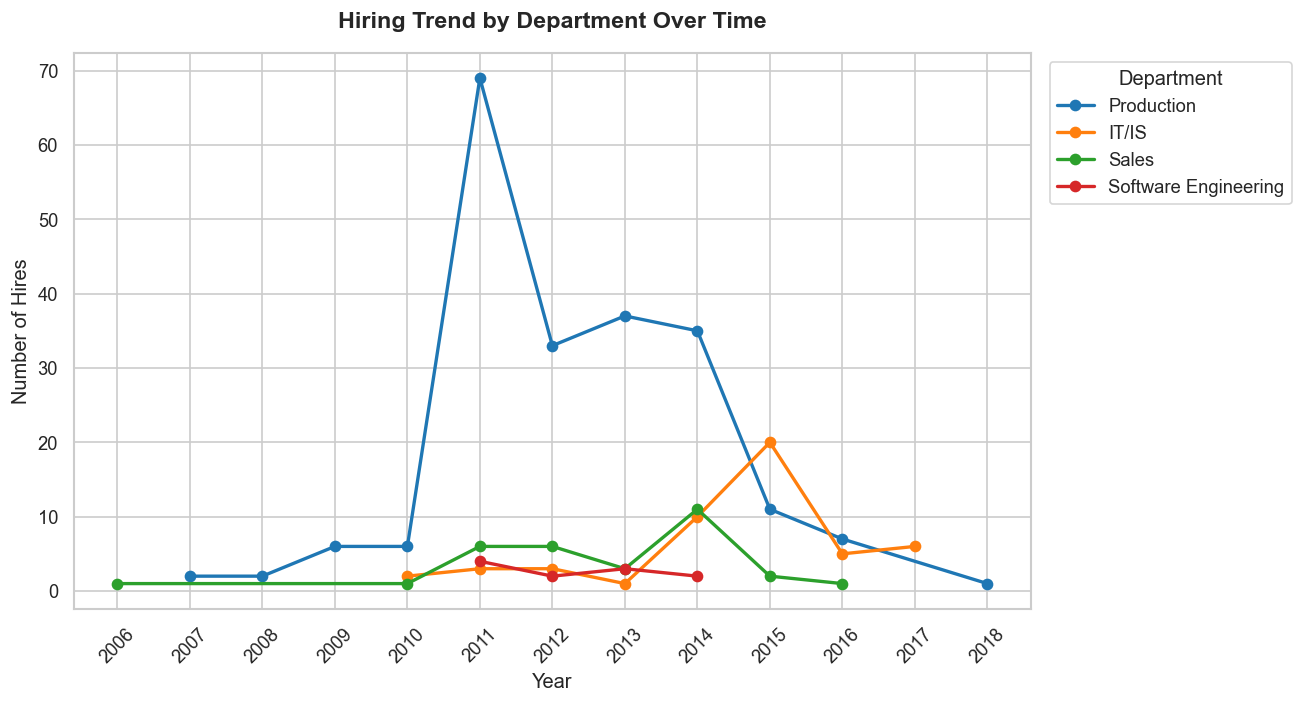

In [8]:
dept_year = df.groupby(['HireYear', 'Department'])['EmpID'].count().reset_index()
dept_year.columns = ['HireYear', 'Department', 'Hires']

# Focus on top 4 departments (others have too few hires to show meaningful trends)
top_depts = ['Production', 'IT/IS', 'Sales', 'Software Engineering']
dept_year_top = dept_year[dept_year['Department'].isin(top_depts)]

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette('tab10', len(top_depts))

for i, dept in enumerate(top_depts):
    data = dept_year_top[dept_year_top['Department'] == dept]
    ax.plot(data['HireYear'], data['Hires'], marker='o', linewidth=2,
            label=dept, color=palette[i])

ax.set_title('Hiring Trend by Department Over Time', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Hires')
ax.legend(title='Department', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/04_dept_trend_over_time.png', bbox_inches='tight')
plt.show()

---
## 5. Attrition Rate by Department

What percentage of employees in each department have left?  
High attrition means that department will need more future hires to replace losses.

## Attrition by Department

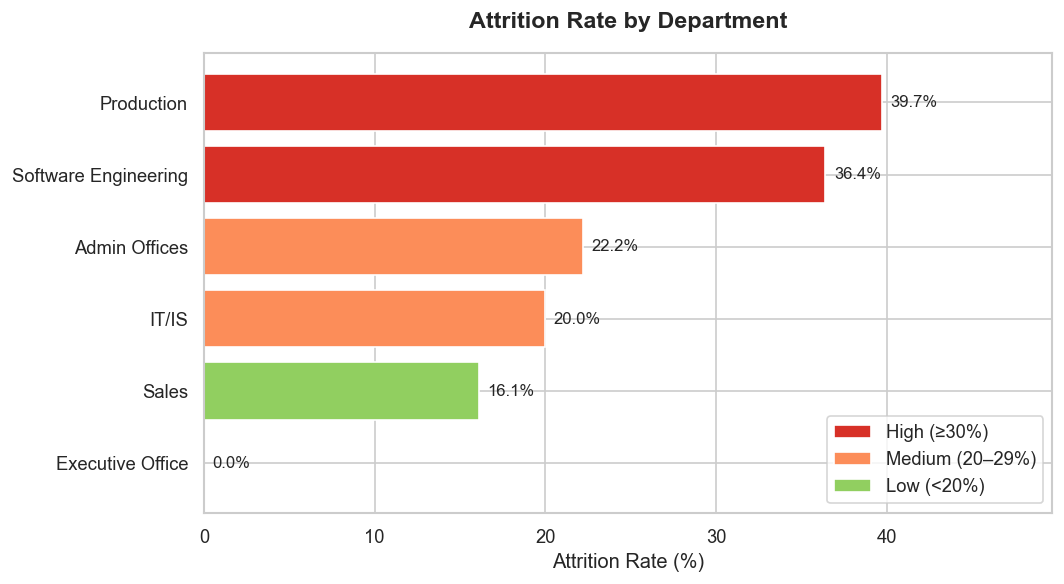

          Department  Total  Active  Terminated  AttritionRate
    Executive Office      1       1           0            0.0
               Sales     31      26           5           16.1
               IT/IS     50      40          10           20.0
       Admin Offices      9       7           2           22.2
Software Engineering     11       7           4           36.4
          Production    209     126          83           39.7


In [9]:
attrition = df.groupby('Department').agg(
    Total      = ('EmpID', 'count'),
    Terminated = ('IsActive', lambda x: (x == 0).sum()),
    Active     = ('IsActive', 'sum')
).reset_index()

attrition['AttritionRate'] = (attrition['Terminated'] / attrition['Total'] * 100).round(1)
attrition = attrition.sort_values('AttritionRate', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d73027' if r >= 30 else '#fc8d59' if r >= 20 else '#91cf60'
          for r in attrition['AttritionRate']]
bars = ax.barh(attrition['Department'], attrition['AttritionRate'],
               color=colors, edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va='center', fontsize=10)

ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Attrition Rate (%)')
ax.set_xlim(0, attrition['AttritionRate'].max() + 10)

# Color legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d73027', label='High (≥30%)'),
                   Patch(facecolor='#fc8d59', label='Medium (20–29%)'),
                   Patch(facecolor='#91cf60', label='Low (<20%)')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/figures/05_attrition_by_department.png', bbox_inches='tight')
plt.show()

print(attrition[['Department','Total','Active','Terminated','AttritionRate']].to_string(index=False))

**Key Insight:** Production has the highest attrition at 39.7%, followed by Software Engineering at 36.4%. These two departments will drive future hiring needs the most.

---
## 6. Termination Reasons

Why are employees leaving?  
Understanding reasons helps HR address root causes and reduce avoidable turnover.

## Termination Reasons Chart

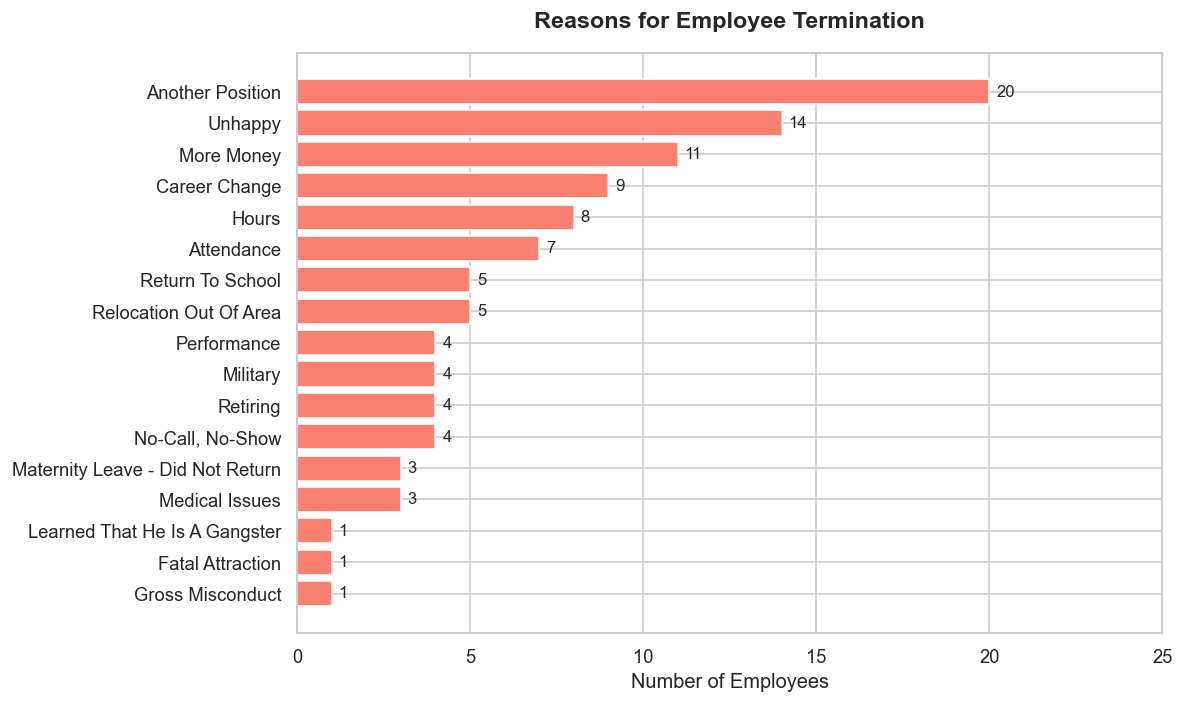

In [10]:
term_reasons = df[df['TermReason'] != 'Still Employed']['TermReason'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(term_reasons.index[::-1], term_reasons.values[::-1],
               color='salmon', edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10)

ax.set_title('Reasons for Employee Termination', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Employees')
ax.set_xlim(0, term_reasons.max() + 5)
plt.tight_layout()
plt.savefig('../outputs/figures/06_termination_reasons.png', bbox_inches='tight')
plt.show()

**Key Insight:** "Another Position" (20) and "Unhappy" (14) are the top voluntary reasons. "More Money" (11) is third — suggesting compensation may be below market for some roles.

---
## 7. Recruitment Source Effectiveness

Which channels bring in the most hires?  
This guides where to invest recruitment budget for future hiring.

## Recruitment Sources Chart

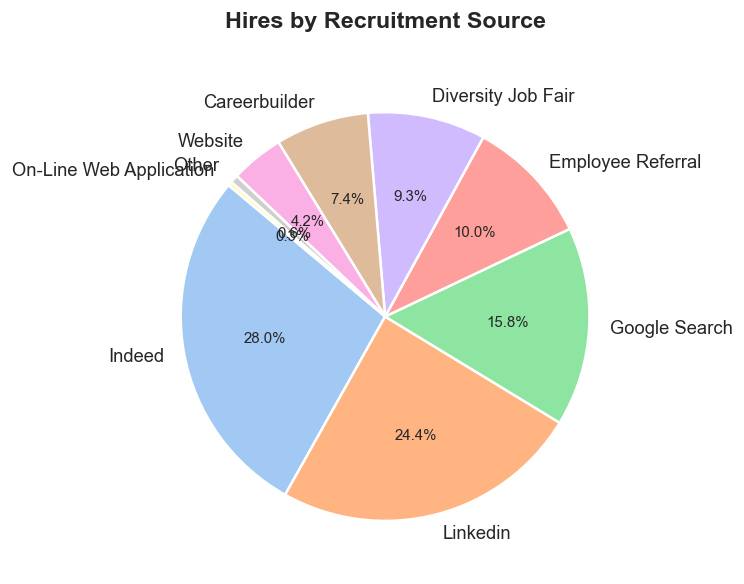

RecruitmentSource
Indeed                     87
Linkedin                   76
Google Search              49
Employee Referral          31
Diversity Job Fair         29
Careerbuilder              23
Website                    13
Other                       2
On-Line Web Application     1


In [12]:
sources = df['RecruitmentSource'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    sources.values,
    labels=sources.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel', len(sources)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

for text in autotexts:
    text.set_fontsize(9)

ax.set_title('Hires by Recruitment Source', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/figures/07_recruitment_sources.png', bbox_inches='tight')
plt.show()

print(sources.to_string())

**Key Insight:** Indeed (28%) and LinkedIn (24.4%) together account for over half of all hires. These should remain the primary recruitment channels going forward.

---
## 8. Hiring Heatmap — Month vs Year

A heatmap reveals which year-month combinations had the most hiring activity, 
showing both annual trends and seasonal patterns simultaneously.

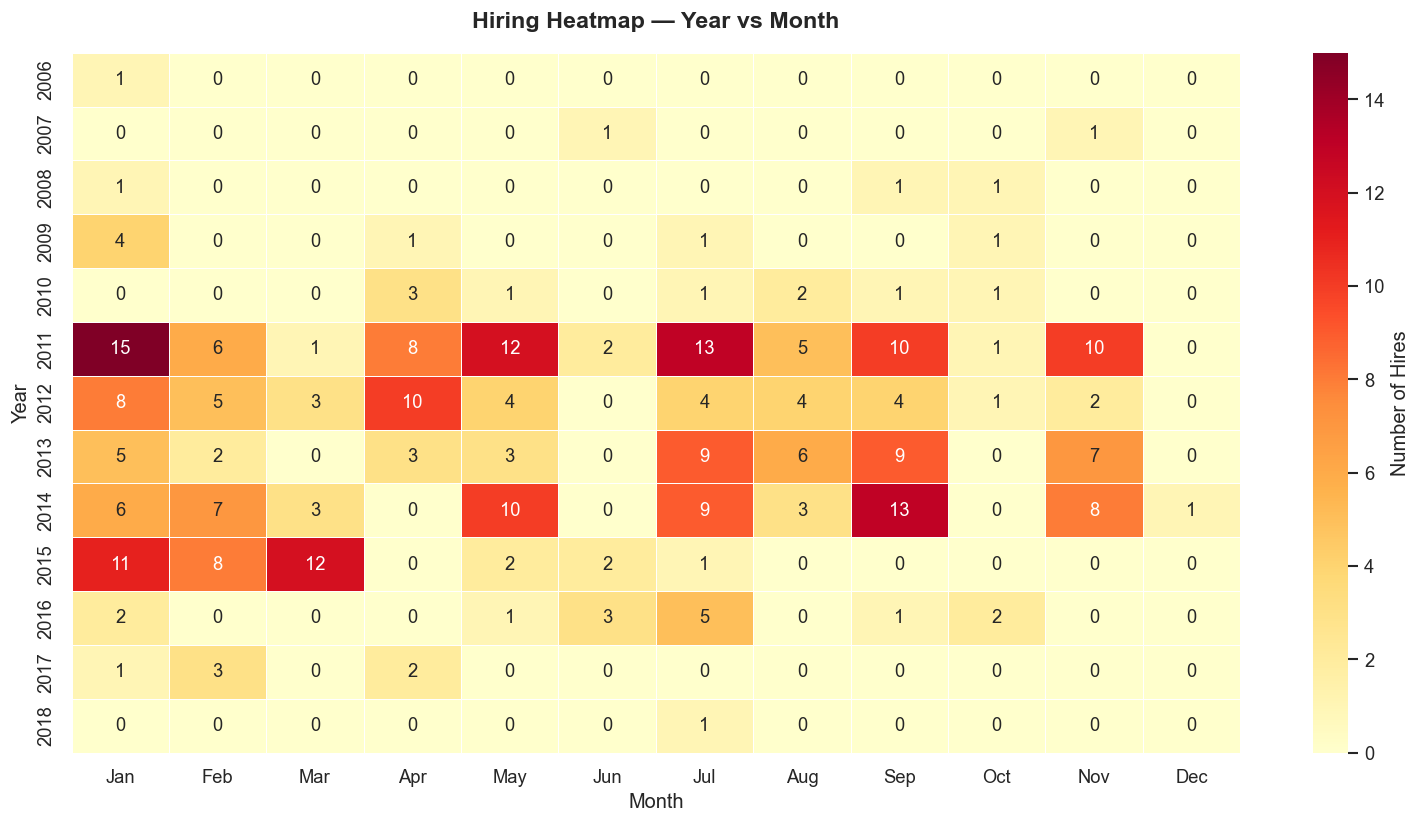

In [13]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_data = df.groupby(['HireYear', 'HireMonthName'])['EmpID'].count().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(columns=month_order, fill_value=0)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Number of Hires'}, ax=ax)

ax.set_title('Hiring Heatmap — Year vs Month', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('../outputs/figures/08_hiring_heatmap.png', bbox_inches='tight')
plt.show()

**Key Insight:** The 2011 row is the most intense across nearly all months, confirming it was the peak recruitment year. January consistently shows high activity across multiple years.

---
## 9. Average Tenure by Department

How long do employees stay in each department on average?  
Shorter tenure means faster turnover and higher future hiring demand.

## Tenure by Department

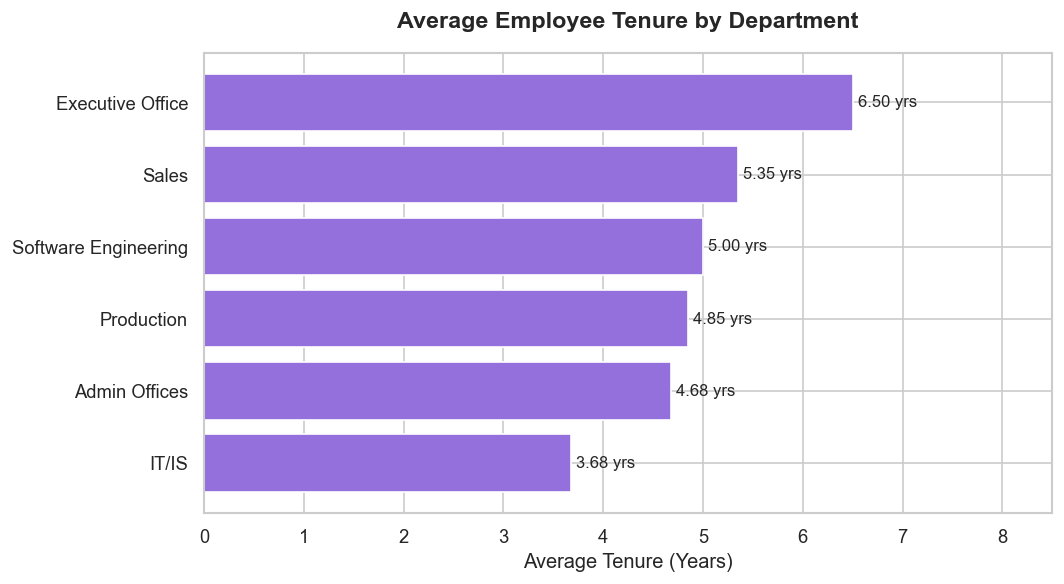

Department
IT/IS                   3.68
Admin Offices           4.68
Production              4.85
Software Engineering    5.00
Sales                   5.35
Executive Office        6.50


In [14]:
tenure_dept = df.groupby('Department')['TenureYears'].mean().round(2).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(tenure_dept.index, tenure_dept.values, color='mediumpurple', edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.2f} yrs", va='center', fontsize=10)

ax.set_title('Average Employee Tenure by Department', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average Tenure (Years)')
ax.set_xlim(0, tenure_dept.max() + 2)
plt.tight_layout()
plt.savefig('../outputs/figures/09_tenure_by_department.png', bbox_inches='tight')
plt.show()

print(tenure_dept.to_string())

---
## 10. EDA Summary — Key Findings

In [15]:
print("=" * 55)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 55)

print(f"\nHiring Trend")
peak_year = df['HireYear'].value_counts().idxmax()
peak_count = df['HireYear'].value_counts().max()
print(f"   Peak hiring year : {peak_year} ({peak_count} hires)")
print(f"   Lowest recent year: {df[df['HireYear'] >= 2014]['HireYear'].value_counts().idxmin()}")

print(f"\nDepartments")
top_dept = df['Department'].value_counts().idxmax()
print(f"   Highest hiring dept   : {top_dept} ({df['Department'].value_counts().max()} hires)")
print(f"   Highest attrition dept: Production (39.7%)")
print(f"   Lowest attrition dept : Sales (16.1%)")

print(f"\nSeasonal Patterns")
peak_month = df.groupby('HireMonthName')['EmpID'].count().idxmax()
print(f"   Peak hiring month : {peak_month}")
print(f"   Quiet months      : June, October, December")

print(f"\nRecruitment Sources")
top_source = df['RecruitmentSource'].value_counts().idxmax()
print(f"   Top source : {top_source} ({df['RecruitmentSource'].value_counts().max()} hires)")
print(f"   Top 2 sources (Indeed + LinkedIn) cover 52.4% of all hires")

print(f"\nAttrition")
total_term = (df['IsActive'] == 0).sum()
print(f"   Total terminated     : {total_term} out of 311")
print(f"   Overall attrition    : {round(total_term/311*100, 1)}%")
print(f"   Top exit reason      : Another Position (20 employees)")
print(f"   Compensation concern : 'More Money' cited by 11 employees")

EDA SUMMARY — KEY FINDINGS

Hiring Trend
   Peak hiring year : 2011 (83 hires)
   Lowest recent year: 2018

Departments
   Highest hiring dept   : Production (209 hires)
   Highest attrition dept: Production (39.7%)
   Lowest attrition dept : Sales (16.1%)

Seasonal Patterns
   Peak hiring month : Jan
   Quiet months      : June, October, December

Recruitment Sources
   Top source : Indeed (87 hires)
   Top 2 sources (Indeed + LinkedIn) cover 52.4% of all hires

Attrition
   Total terminated     : 104 out of 311
   Overall attrition    : 33.4%
   Top exit reason      : Another Position (20 employees)
   Compensation concern : 'More Money' cited by 11 employees


---
## Step 2 Completed — EDA Summary

| Analysis | Chart Saved |
|---|---|
| Annual hiring trend | `01_hires_per_year.png` |
| Hires by department | `02_hires_by_department.png` |
| Seasonal patterns | `03_seasonal_hiring.png` |
| Department trend over time | `04_dept_trend_over_time.png` |
| Attrition by department | `05_attrition_by_department.png` |
| Termination reasons | `06_termination_reasons.png` |
| Recruitment sources | `07_recruitment_sources.png` |
| Hiring heatmap | `08_hiring_heatmap.png` |
| Tenure by department | `09_tenure_by_department.png` |

**Next Step -> Notebook 03: Forecasting Model**